In [2]:
import pandas as pd        #Importing Library

In [3]:
py = pd.read_excel(r"D:\Data Analyst Project\Dataset\Real Mart Sales.xlsx")           #Importing Dataset

In [4]:
py.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,747-39-8913,C,Hyderabad,Member,Male,Sports and travel,10.17,1,0.5085,10.6785,2019-07-02 00:00:00,14:15:00,Cash,10.17,4.761905,0.5085,5.9
1,784-21-9238,C,Mumbai,Member,Male,Sports and travel,10.17,1,0.5085,10.6785,2019-07-02 00:00:00,14:15:00,Cash,10.17,4.761905,0.5085,5.9
2,308-39-1707,C,Delhi,Normal,Female,Fashion accessories,12.09,1,0.6045,12.6945,1/26/2019,18:19:00,Cash,12.09,4.761905,0.6045,8.2
3,331-98-7546,A,Mumbai,Normal,Male,Fashion accessories,12.09,1,0.6045,12.6945,1/26/2019,18:19:00,Cash,12.09,4.761905,0.6045,8.2
4,531-63-1563,C,Delhi,Normal,Female,Fashion accessories,12.09,1,0.6045,12.6945,1/26/2019,18:19:00,Cash,12.09,4.761905,0.6045,8.2


In [5]:
py.shape               #Checking rows

(2064, 17)

In [6]:
py.info()         #information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2064 entries, 0 to 2063
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               2064 non-null   object 
 1   Branch                   2064 non-null   object 
 2   City                     2064 non-null   object 
 3   Customer type            2064 non-null   object 
 4   Gender                   2064 non-null   object 
 5   Product line             2064 non-null   object 
 6   Unit price               2064 non-null   float64
 7   Quantity                 2064 non-null   int64  
 8   Tax 5%                   2064 non-null   float64
 9   Total                    2064 non-null   float64
 10  Date                     2064 non-null   object 
 11  Time                     2064 non-null   object 
 12  Payment                  2064 non-null   object 
 13  cogs                     2064 non-null   float64
 14  gross margin percentage 

In [7]:
py.describe()              #Statistics

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2.064000e+03,2064.000000,2064.000000
mean,55.965858,5.434109,15.210236,319.414960,304.204724,4.761905e+00,15.210236,7.198353
std,26.542573,2.938787,11.689612,245.481854,233.792242,7.817864e-14,11.689612,2.292976
min,10.080000,1.000000,0.508500,10.678500,10.170000,4.761905e+00,0.508500,1.100000
25%,32.900000,3.000000,5.679000,119.259000,113.580000,4.761905e+00,5.679000,5.500000
50%,55.055000,5.000000,11.928250,250.493250,238.565000,4.761905e+00,11.928250,7.050000
75%,78.327500,8.000000,22.357250,469.502250,447.145000,4.761905e+00,22.357250,8.700000
max,99.960000,10.000000,49.650000,1042.650000,993.000000,4.761905e+00,49.650000,18.000000


In [8]:
py.isnull().sum()        #Data Cleaning    #checking missing values

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [9]:
py.duplicated().sum()

np.int64(0)

In [10]:
py.drop_duplicates(inplace=True)        #remove duplicates

In [11]:
#Feature Engineering
#Convert Date
py["Date"] = pd.to_datetime(py["Date"])         

In [12]:
#Create new columns
py["Year"] = py["Date"].dt.year
py["Month"] = py["Date"].dt.month_name()
py["Day"] = py["Date"].dt.day_name()

In [13]:
#EDA
#Total Sales
py["Total"].sum()

np.float64(659272.4775)

In [14]:
#avg rating
py["Rating"].mean()

np.float64(7.198352713178294)

In [15]:
#Tot Customers
py["Invoice ID"].count()

np.int64(2064)

In [16]:
#sales by city
py.groupby("City")["Total"].sum()

City
Delhi        128133.8940
Hyderabad    207461.3730
Mumbai       323677.2105
Name: Total, dtype: float64

In [17]:
#Sales by productline
py.groupby("Product line")["Total"].sum()

Product line
Electronic accessories    118324.8360
Fashion accessories        89879.0235
Food and beverages        220154.5185
Health and beauty          59129.6370
Home and lifestyle         69151.5930
Sports and travel         102632.8695
Name: Total, dtype: float64

In [18]:
#sales by gender
py.groupby("Gender")["Total"].sum()

Gender
Female    190095.5700
Male      469176.9075
Name: Total, dtype: float64

In [19]:
#Sales by payment method
py.groupby("Payment")["Total"].sum()

Payment
Cash           399492.0300
Credit card    123692.7090
Ewallet        136087.7385
Name: Total, dtype: float64

In [20]:
#Sales by month
py.groupby("Month")["Total"].sum()

Month
April         16339.0605
August        28298.8335
December      21567.1785
February     136829.2800
January      175419.5310
July          24104.1255
June          17952.6270
March        149251.7985
May           21986.0865
November      18577.1670
October       20475.1575
September     28471.6320
Name: Total, dtype: float64

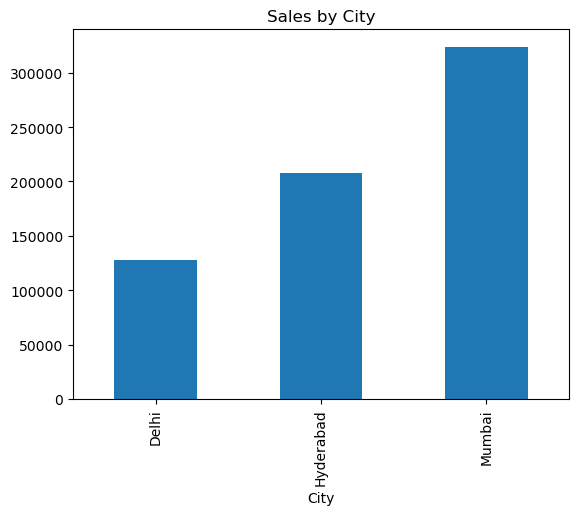

In [21]:
#CHARTS
import matplotlib.pyplot as plt
py.groupby("City")["Total"].sum().plot(kind="bar")
plt.title("Sales by City")
plt.show()